In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Student engagement raw data
lms_data = {
    'student_id': [101, 102, 103, 104, 105],
    'student_name': ['Ahmad', 'Sara', 'Omar', 'Lina', 'Yousef'],
    'course_title': ['Python Analytics', 'Power BI', 'SQL Basics', 'Python Analytics', 'Power BI'],
    'completion_rate_pct': [85, 20, 95, 40, 10],
    'days_since_last_login': [2, 22, 1, 16, 30]
}

df_lms = pd.DataFrame(lms_data)

In [18]:
# Threshold definition for inactivity risk
threshold_days = 14

# Classify students based on the inactivity threshold
df_lms['risk_level'] = df_lms['days_since_last_login'].apply(
    lambda x: 'High Risk' if x > threshold_days else 'Active'
)

# Display the processed dataframe
display(df_lms)

,student_id,student_name,course_title,completion_rate_pct,days_since_last_login,risk_level
0,101,Ahmad,Python Analytics,85,2,Active
1,102,Sara,Power BI,20,22,High Risk
2,103,Omar,SQL Basics,95,1,Active
3,104,Lina,Python Analytics,40,16,High Risk
4,105,Yousef,Power BI,10,30,High Risk


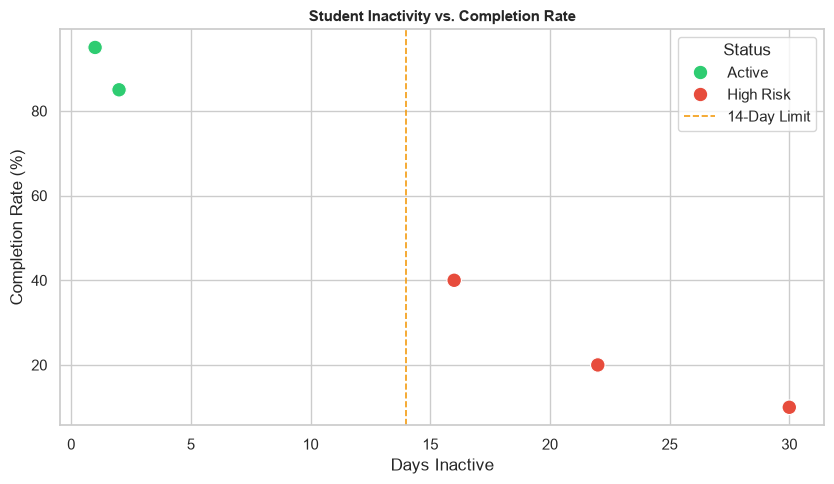

In [ ]:
plt.figure(figsize=(8.5, 5))

# Scatter plot for inactivity vs completion rate
plot = sns.scatterplot(
    data=df_lms,
    x='days_since_last_login',
    y='completion_rate_pct',
    hue='risk_level',
    palette={'High Risk': '#e74c3c', 'Active': '#2ecc71'},
    s=110
)

# Reference line for 14-day inactivity limit
plt.axvline(x=threshold_days, color='#f39c12', linestyle='--', linewidth=1.2, label='14-Day Limit')

plt.title('Student Inactivity vs. Completion Rate', fontsize=11, fontweight='bold')
plt.xlabel('Days Inactive')
plt.ylabel('Completion Rate (%)')
plt.legend(title='Status', loc='upper right')

plt.tight_layout()
plt.savefig('lms_inactivity_risk.png', dpi=300)
plt.show()